# ARES 2023-68A — Our Own Tranche Price (BR + full stack)

We compute an **independent price** for the ARES 2023-68A **BR** tranche (and, as an
extension, every rated class) **as of the valuation date 2026-05-25** — the deal's
May-2026 monthly trustee determination date (`Periodic_Report_05_25_26` /
`Monthly_Report_05_26.pdf`). All terms, balances, the collateral tape and the SOFR
fixing come from that snapshot. Two methods:

**Method 1 — Expected-cash-flow / loss view (our credit opinion).**
Project the tranche's quarterly floating cash flows, **haircut principal by our
Monte-Carlo expected loss** `E[loss]` (from `br_montecarlo_results.csv` for BR, and a
consistent per-tranche re-simulation for the rest), and discount at
`SOFR + credit spread`. Base credit spread = the tranche's **issue spread**; we also
solve price across a spread range for sensitivity.

**Method 2 — Market-convention discount-margin (DM) pricing.**
Discount the **promised** cash flows (no explicit loss haircut) at a **discount margin**
taken as a parameter (comparable BB/BBB CLO-mezz secondary spreads). Price is reported
as a function of DM.

**Key inputs & assumptions** (all parameters, editable in the next cell):
- Tranche terms from the trustee MV overview (`market_value_overview_ares_2023.xlsx`):
  per-class balance, all-in coupon, and derived spread = coupon − 3M SOFR.
  BR = \$52.5M, coupon 5.367%, spread ≈ 1.70%.
- 3M SOFR base = **3.668%**, assumed **flat forward** (parameter).
- Quarterly pay, `n = 4`.
- **WAL ≈ 5.5y** (parameter). Approximated from the deal's reinvestment-end + stated
  maturity; senior classes amortize faster, so a single WAL is conservative for seniors
  and roughly right for mezz like BR.
- Loss inputs from the one-factor Gaussian-copula Monte Carlo; **base ρ = 0.20**, with a
  ρ grid (0.05–0.40) for correlation/tail sensitivity.

> **Loss convention:** in Method 1 the expected loss is applied to **principal at
> redemption** (coupons paid in full until then). This is the standard "loss hits the
> bullet" assumption; timing of loss is not modelled (a simplification we state
> explicitly). No market price is fabricated — a `MARKET_PRICE` slot is provided at the
> end for comparison when a quote is available.

In [1]:
import os, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import norm
warnings.filterwarnings('ignore')

# ---------- global market / deal parameters ----------
# Valuation date = the deal's May-2026 monthly trustee determination date
# (source: Periodic_Report_05_25_26 / Monthly_Report_05_26.pdf). All terms,
# balances, the collateral tape and the SOFR fixing are as of this snapshot.
VALUATION_DATE = '2026-05-25'
REPORT_SOURCE  = 'ARES 2023-68A monthly trustee report (period ending 2026-05-25)'
SOFR      = 0.03668     # 3M SOFR, flat forward assumption (parameter)
FREQ      = 4           # quarterly pay
WAL       = 5.5         # yrs to (blended) redemption; assumption ~5-6y (parameter)
BASE_RHO  = 0.20        # base correlation for the base-case price

# Method 1: base discount credit spread = tranche's own issue spread (set per-tranche).
# Sensitivity grid of *discount* credit spreads (loss fixed at base):
M1_SPREADS = np.arange(0.0150, 0.0401, 0.0025)   # 150-400 bps

# Method 2: discount-margin grid = comparable BB/BBB CLO-mezz secondary spreads
# (assumption; state source when a live quote sheet is available):
M2_DMS     = np.arange(0.0250, 0.0451, 0.0025)   # 250-450 bps
M2_MKT_DM  = 0.0300                               # single headline market DM (300 bps)

# market price slot -- do NOT fabricate; set when a quote is available (% of par)
MARKET_PRICE = None

# resolve data paths whether run from project/notebooks or repo root
def _find(*cands):
    return next(p for p in cands if os.path.exists(p))
MV_PATH = _find('../../data/ARES_2023_68A/market_value_overview_ares_2023.xlsx',
                '../data/ARES_2023_68A/market_value_overview_ares_2023.xlsx',
                'data/ARES_2023_68A/market_value_overview_ares_2023.xlsx')
MC_PATH = _find('output/br_montecarlo_results.csv', '../output/br_montecarlo_results.csv')
TAPE_PATH = _find('output/lld_ares_2023_derived.csv', '../output/lld_ares_2023_derived.csv')
OUTDIR = 'output' if os.path.isdir('output') else '.'
print(f'VALUATION DATE = {VALUATION_DATE}  ({REPORT_SOURCE})')
print(f'SOFR={SOFR:.3%}  FREQ={FREQ}  WAL={WAL}y  base rho={BASE_RHO}')

VALUATION DATE = 2026-05-25  (ARES 2023-68A monthly trustee report (period ending 2026-05-25))
SOFR=3.668%  FREQ=4  WAL=5.5y  base rho=0.2


## 1. Tranche terms (from the trustee MV overview)

We read every class's current balance and all-in coupon, and **derive each tranche's
spread** as `spread = coupon − SOFR_base`. This reproduces BR's 1.70% from its 5.367%
coupon, and gives us the issue spread we use as Method-1 base discount spread and as a
reference DM.

In [2]:
mv = pd.read_excel(MV_PATH)
mv['balance'] = mv['Curr(000)'].astype(float) * 1_000
mv['coupon']  = mv['Cpn'].astype(float) / 100.0          # all-in coupon (decimal)
mv['spread']  = (mv['coupon'] - SOFR).clip(lower=0)      # derived spread over SOFR

terms = mv[['Class', 'balance', 'coupon', 'spread']].copy()
terms['%_bal'] = terms['balance'] / terms['balance'].sum()
# rated debt = everything except the 0-coupon SUB (equity) -- SUB is priced on NAV, not DM
RATED = terms[terms['coupon'] > 0]['Class'].tolist()
print('BR check: coupon={:.3%}  spread={:.3%}'.format(
      float(terms.loc[terms.Class=='BR','coupon'].iloc[0]),
      float(terms.loc[terms.Class=='BR','spread'].iloc[0])))
disp = terms.copy()
disp['balance'] = disp['balance'].map('${:,.0f}'.format)
disp['coupon']  = disp['coupon'].map('{:.3%}'.format)
disp['spread']  = disp['spread'].map('{:.2%}'.format)
disp['%_bal']   = disp['%_bal'].map('{:.1%}'.format)
print(disp.to_string(index=False))

BR check: coupon=5.367%  spread=1.699%
Class      balance  coupon spread %_bal
  A1R $307,500,000  4.977%  1.31% 61.9%
  A2R  $20,000,000  5.267%  1.60%  4.0%
   BR  $52,500,000  5.367%  1.70% 10.6%
   CR  $30,000,000  5.617%  1.95%  6.0%
  D1R  $27,500,000  6.667%  3.00%  5.5%
  D2R   $7,500,000  7.817%  4.15%  1.5%
   ER  $15,000,000  9.667%  6.00%  3.0%
    F     $500,000 13.747% 10.08%  0.1%
  SUB  $35,900,000  0.000%  0.00%  7.2%


## 2. BR expected loss & tail (from the Monte Carlo)

BR's expected loss and tail metrics come straight from `br_montecarlo_results.csv`
(one-factor Gaussian copula, 50k paths, ρ grid). The **base price** uses `E[BR loss]` at
**ρ = 0.20**; the ρ grid drives the correlation sensitivity of Method 1.

In [3]:
mc = pd.read_csv(MC_PATH)
EL_BY_RHO = mc.set_index('rho')['E[BR loss]']
EL_BR_BASE = float(EL_BY_RHO.loc[BASE_RHO])
print('BR loss metrics by rho:')
print(mc.set_index('rho')[['P(BR loss>0)','E[BR loss]','99% loss','ES(99%)']].round(5).to_string())
print(f'\nbase E[BR loss] (rho={BASE_RHO}) = {EL_BR_BASE:.4%}')

BR loss metrics by rho:
      P(BR loss>0)  E[BR loss]  99% loss  ES(99%)
rho                                              
0.05       0.00030     0.00004   0.00000  0.00004
0.10       0.00576     0.00136   0.00000  0.00136
0.20       0.03126     0.01190   0.47549  0.76396
0.30       0.05994     0.02937   1.00000  1.00000
0.40       0.08568     0.04866   1.00000  1.00000

base E[BR loss] (rho=0.2) = 1.1903%


## 3. The pricing kernel

A floating-rate tranche priced as the PV of quarterly coupons plus a loss-adjusted
principal bullet at WAL. One function serves **both** methods:

- **Method 1 (loss view):** pass `el = E[loss]` (haircuts the principal) and
  `disc_spread = credit spread` on top of SOFR.
- **Method 2 (DM):** pass `el = 0` (promised cash flows) and `disc_spread = DM`.

$$\text{Price} = 100\sum_{t=1}^{n}\frac{(\text{SOFR}+s)/m}{(1+(\text{SOFR}+d)/m)^t}
 \;+\; 100\,\frac{(1-\text{EL})}{(1+(\text{SOFR}+d)/m)^{n}}$$

where `m = FREQ`, `s` = coupon spread, `d` = discount spread/DM, `n = round(WAL·m)`.

In [4]:
def price_frn(disc_spread, cpn_spread, el=0.0, wal=WAL, sofr=SOFR, freq=FREQ):
    # disc_spread : credit spread (M1) or discount margin (M2), over SOFR
    # cpn_spread  : tranche's coupon spread over SOFR
    # el          : expected loss applied to principal at redemption (0 = promised CFs)
    n  = int(round(wal * freq))
    cf = np.full(n, (sofr + cpn_spread) / freq)   # coupon per $1 face
    cf[-1] += (1.0 - el)                          # loss-haircut principal at WAL
    t  = np.arange(1, n + 1)
    df = 1.0 / (1.0 + (sofr + disc_spread) / freq) ** t
    return 100.0 * float((cf * df).sum())

# sanity: promised CFs discounted at the coupon spread -> par
BR_SPREAD = float(terms.loc[terms.Class=='BR','spread'].iloc[0])
print(f'par check (BR, DM=coupon spread {BR_SPREAD:.2%}, no loss) = '
      f'{price_frn(BR_SPREAD, BR_SPREAD, el=0):.2f}')

par check (BR, DM=coupon spread 1.70%, no loss) = 100.00


## 4. Method 1 — BR loss-view price

Base price: haircut BR's principal by `E[BR loss]` at ρ = 0.20 and discount at
`SOFR + issue spread (170 bps)`. Then two sensitivities:
1. **Correlation** — EL varies along the ρ grid (discount spread fixed at issue).
2. **Discount spread** — 150–400 bps (EL fixed at base).

In [5]:
m1_br_base = price_frn(BR_SPREAD, BR_SPREAD, el=EL_BR_BASE)
print(f'Method 1 BR base price = {m1_br_base:.2f}  '
      f'(EL={EL_BR_BASE:.3%}, disc spread={BR_SPREAD:.2%})')

# (1) correlation sensitivity: EL varies with rho, discount spread fixed at issue
m1_rho = pd.DataFrame({'rho': EL_BY_RHO.index, 'EL': EL_BY_RHO.values,
                       'price': [price_frn(BR_SPREAD, BR_SPREAD, el=e) for e in EL_BY_RHO.values]})
# (2) discount-spread sensitivity: EL fixed at base
m1_spr = pd.DataFrame({'disc_spread_bps': (M1_SPREADS*1e4).round().astype(int),
                       'price': [price_frn(s, BR_SPREAD, el=EL_BR_BASE) for s in M1_SPREADS]})
print('\nBR price vs correlation (EL):'); print(m1_rho.round(4).to_string(index=False))
print('\nBR price vs discount spread (EL fixed):'); print(m1_spr.round(3).to_string(index=False))

m1_spr.to_csv(f'{OUTDIR}/br_pricing_method1_spread.csv', index=False)

Method 1 BR base price = 99.11  (EL=1.190%, disc spread=1.70%)

BR price vs correlation (EL):
 rho     EL   price
0.05 0.0000 99.9972
0.10 0.0014 99.8988
0.20 0.0119 99.1122
0.30 0.0294 97.8092
0.40 0.0487 96.3708

BR price vs discount spread (EL fixed):
 disc_spread_bps   price
             150 100.050
             175  98.873
             200  97.713
             225  96.568
             250  95.438
             275  94.323
             300  93.223
             325  92.138
             350  91.068
             375  90.012
             400  88.969


## 5. Method 2 — BR market-convention (DM) price

Discount BR's **promised** cash flows (no loss haircut) at a discount margin. The DM grid
(250–450 bps) brackets where BB/BBB CLO mezz has traded in secondary; treat the exact
level as an input to be refreshed from a dealer run/BWIC sheet.

In [6]:
m2_br = pd.DataFrame({'DM_bps': (M2_DMS*1e4).round().astype(int),
                      'price': [price_frn(dm, BR_SPREAD, el=0.0) for dm in M2_DMS]})
m2_br_hdr = price_frn(M2_MKT_DM, BR_SPREAD, el=0.0)
print('BR price vs discount margin (promised CFs):')
print(m2_br.round(3).to_string(index=False))
print(f'\nheadline: DM={M2_MKT_DM:.2%} -> price {m2_br_hdr:.2f}')
m2_br.to_csv(f'{OUTDIR}/br_pricing_method2_dm.csv', index=False)

BR price vs discount margin (promised CFs):
 DM_bps  price
    250 96.288
    275 95.162
    300 94.051
    325 92.955
    350 91.873
    375 90.806
    400 89.753
    425 88.714
    450 87.689

headline: DM=3.00% -> price 94.05


## 6. Extension — expected loss for **every** tranche (consistent re-simulation)

`br_montecarlo_results.csv` only carries BR. To price the whole stack on Method 1 we need
each class's `E[loss]`. We re-run the **same** one-factor Gaussian-copula pool-loss engine
(same seed, PD/LGD tape, Beta recoveries) and remap each simulated pool loss onto **every**
class's attach/detach points. We validate that this reproduces the BR EL from the CSV.

In [7]:
df = pd.read_csv(TAPE_PATH)
df['LGD'] = df['LGD'].fillna(df['LGD'].mean())
balance  = df['Current Balance'].to_numpy(float)
pd_cum   = df['PD'].to_numpy(float).clip(1e-6, 1.0)
lgd      = df['LGD'].to_numpy(float).clip(0.01, 0.99)
rec_mean = 1.0 - lgd
L        = len(df)
pool_par = balance.sum()
thr      = norm.ppf(pd_cum)                 # default threshold per loan

SEED, N_PATHS, CHUNK, K_REC = 42, 50_000, 5_000, 20   # match br_monte_carlo.ipynb

# attach/detach per class: junior classes' balance / collateral par (thinnest = equity up)
mv_stack = mv.copy()
mv_stack['cum_jr'] = mv_stack['balance'][::-1].cumsum()[::-1].shift(-1).fillna(0.0)
mv_stack['attach'] = mv_stack['cum_jr'] / pool_par
mv_stack['detach'] = mv_stack['attach'] + mv_stack['balance'] / pool_par

def pool_loss_paths(rho, n_paths=N_PATHS, chunk=CHUNK):
    rng = np.random.default_rng(SEED)
    a, b = np.sqrt(rho), np.sqrt(1 - rho)
    pool = np.empty(n_paths)
    for s in range(0, n_paths, chunk):
        m = min(chunk, n_paths - s)
        M = rng.standard_normal(m)
        Z = rng.standard_normal((m, L))
        default = (a * M[:, None] + b * Z) < thr[None, :]
        mu  = np.clip(rec_mean[None, :], 0.01, 0.99)
        rec = rng.beta(mu * K_REC, (1 - mu) * K_REC)
        pool[s:s+m] = (default * balance[None, :] * (1 - rec)).sum(1) / pool_par
    return pool

def tranche_loss(pool, attach, detach):
    return np.clip((pool - attach) / (detach - attach), 0, 1)

# per-tranche EL across the rho grid
rho_grid = list(EL_BY_RHO.index)
el_records = []
for rho in rho_grid:
    pool = pool_loss_paths(rho)
    for _, r in mv_stack.iterrows():
        if r['detach'] <= r['attach']:
            continue
        tl = tranche_loss(pool, r['attach'], r['detach'])
        el_records.append({'Class': r['Class'], 'rho': rho, 'attach': r['attach'],
                           'detach': r['detach'], 'EL': tl.mean(),
                           'loss99': np.percentile(tl, 99)})
el_all = pd.DataFrame(el_records)

# validate BR against the CSV
br_sim = float(el_all[(el_all.Class=='BR') & (el_all.rho==BASE_RHO)]['EL'].iloc[0])
print(f'BR EL: sim={br_sim:.4%}  vs CSV={EL_BR_BASE:.4%}  (diff {br_sim-EL_BR_BASE:+.4%})')
print('\nEL by class at base rho:')
print(el_all[el_all.rho==BASE_RHO][['Class','attach','detach','EL','loss99']]
      .round(4).to_string(index=False))

BR EL: sim=1.1903%  vs CSV=1.1903%  (diff +0.0000%)

EL by class at base rho:
Class  attach  detach     EL  loss99
  A1R  0.3839  1.0088 0.0000  0.0000
  A2R  0.3433  0.3839 0.0014  0.0000
   BR  0.2366  0.3433 0.0119  0.4755
   CR  0.1756  0.2366 0.0627  1.0000
  D1R  0.1197  0.1756 0.1825  1.0000
  D2R  0.1045  0.1197 0.3174  1.0000
   ER  0.0740  0.1045 0.4485  1.0000
    F  0.0730  0.0740 0.5529  1.0000
  SUB  0.0000  0.0730 0.8208  1.0000


## 7. Price the whole stack — both methods

For each rated class we report:
- **M1 (loss view):** own `E[loss]` at ρ = 0.20, discounted at `SOFR + own issue spread`.
- **M2 (market DM):** promised CFs at the headline market DM (300 bps) — a single common
  discount margin so classes are comparable; refine per-rating in practice.
- **M2 @ own spread:** promised CFs discounted at the class's own issue spread (≈ par
  check / relative-value anchor).

SUB (equity, 0 coupon) is excluded — it is a NAV/residual claim, not a DM-priced bond.

In [8]:
el_base = el_all[el_all.rho==BASE_RHO].set_index('Class')['EL']
rows = []
for cls in RATED:
    s   = float(terms.loc[terms.Class==cls,'spread'].iloc[0])
    el  = float(el_base.get(cls, 0.0))
    rows.append({
        'Class': cls,
        'spread_bps': round(s*1e4),
        'EL_base':    el,
        'M1_lossview': price_frn(s, s, el=el),
        'M2_mktDM300': price_frn(M2_MKT_DM, s, el=0.0),
        'M2_ownspread': price_frn(s, s, el=0.0),
    })
stack = pd.DataFrame(rows)
stack.insert(0, 'valuation_date', VALUATION_DATE)
show = stack.drop(columns='valuation_date').copy()
show['EL_base'] = show['EL_base'].map('{:.2%}'.format)
for c in ['M1_lossview','M2_mktDM300','M2_ownspread']:
    show[c] = show[c].map('{:.2f}'.format)
print(show.to_string(index=False))
stack.round(4).to_csv(f'{OUTDIR}/tranche_pricing_all.csv', index=False)
print(f'\nwrote {OUTDIR}/tranche_pricing_all.csv')

Class  spread_bps EL_base M1_lossview M2_mktDM300 M2_ownspread
  A1R         131   0.00%      100.00       92.27       100.00
  A2R         160   0.14%       99.89       93.59       100.00
   BR         170   1.19%       99.11       94.05       100.00
   CR         195   6.27%       95.39       95.19       100.00
  D1R         300  18.25%       87.31      100.00       100.00
  D2R         415  31.74%       79.27      105.25       100.00
   ER         600  44.85%       73.48      113.71       100.00
    F        1008  55.29%       73.71      132.37       100.00

wrote output/tranche_pricing_all.csv


## 8. BR headline summary & outputs

In [9]:
summary = pd.DataFrame({
    'valuation_date': VALUATION_DATE,
    'method': ['M1 loss-view (base)', f'M2 DM={int(M2_MKT_DM*1e4)}bps'],
    'price':  [round(m1_br_base, 2), round(m2_br_hdr, 2)],
    'note':   [f'EL={EL_BR_BASE:.2%}, disc=issue spread',
               'promised CFs, DM {}bps'.format(int(M2_MKT_DM*1e4))],
})
summary.to_csv(f'{OUTDIR}/br_pricing_summary.csv', index=False)
print(summary.to_string(index=False))
print('\nwrote br_pricing_summary.csv, br_pricing_method1_spread.csv, '
      'br_pricing_method2_dm.csv, tranche_pricing_all.csv')

valuation_date              method  price                        note
    2026-05-25 M1 loss-view (base)  99.11 EL=1.19%, disc=issue spread
    2026-05-25        M2 DM=300bps  94.05     promised CFs, DM 300bps

wrote br_pricing_summary.csv, br_pricing_method1_spread.csv, br_pricing_method2_dm.csv, tranche_pricing_all.csv


## 9. Charts

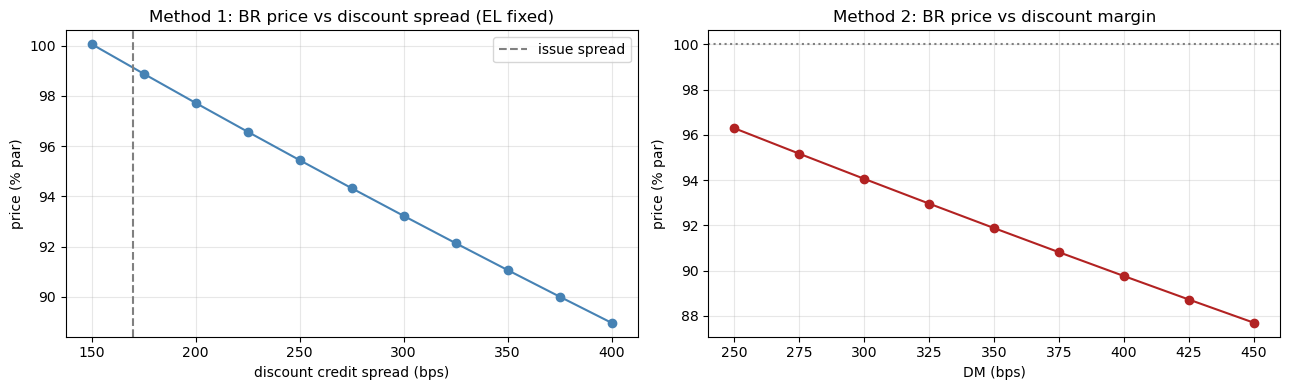

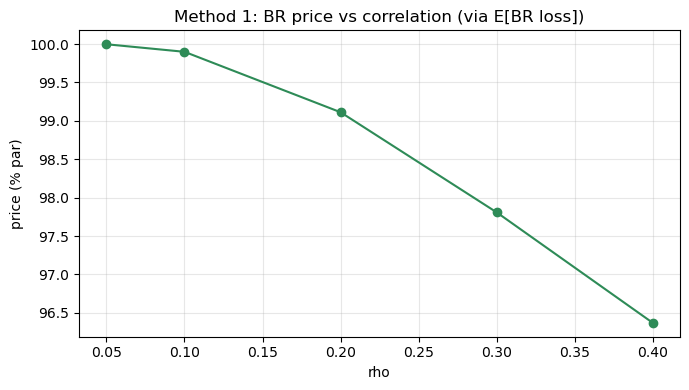

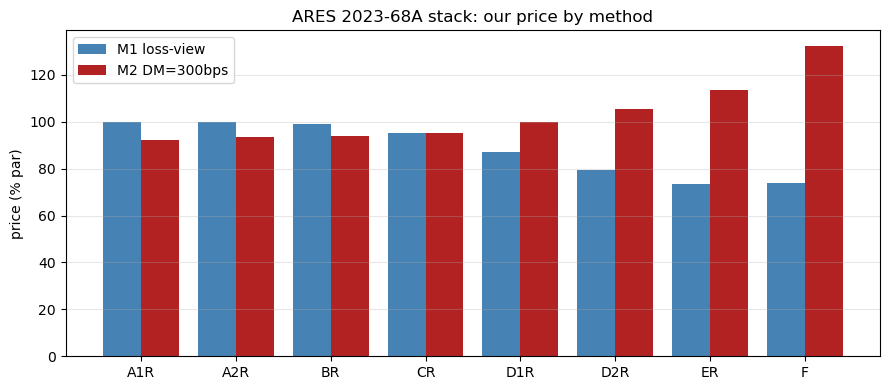

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(m1_spr['disc_spread_bps'], m1_spr['price'], '-o', color='steelblue')
ax[0].axvline(BR_SPREAD*1e4, ls='--', color='grey', label='issue spread')
ax[0].set_title('Method 1: BR price vs discount spread (EL fixed)')
ax[0].set_xlabel('discount credit spread (bps)'); ax[0].set_ylabel('price (% par)')
ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(m2_br['DM_bps'], m2_br['price'], '-o', color='firebrick')
ax[1].axhline(100, ls=':', color='grey')
ax[1].set_title('Method 2: BR price vs discount margin')
ax[1].set_xlabel('DM (bps)'); ax[1].set_ylabel('price (% par)'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 4))
plt.plot(m1_rho['rho'], m1_rho['price'], '-o', color='seagreen')
plt.title('Method 1: BR price vs correlation (via E[BR loss])')
plt.xlabel('rho'); plt.ylabel('price (% par)'); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

# whole-stack: M1 loss-view vs M2 market-DM
xp = np.arange(len(stack))
plt.figure(figsize=(9, 4))
plt.bar(xp-0.2, stack['M1_lossview'], 0.4, label='M1 loss-view', color='steelblue')
plt.bar(xp+0.2, stack['M2_mktDM300'], 0.4, label=f'M2 DM={int(M2_MKT_DM*1e4)}bps', color='firebrick')
plt.xticks(xp, stack['Class']); plt.ylabel('price (% par)')
plt.title('ARES 2023-68A stack: our price by method'); plt.legend(); plt.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

## 10. Market comparison (activate when a quote is available)

No market price is fabricated. Set `MARKET_PRICE` (% of par) in the params cell to light
up the richness/cheapness read and the market-implied DM.

In [11]:
if MARKET_PRICE is None:
    print('MARKET PRICE NOT PROVIDED - comparison pending.')
    print('Set MARKET_PRICE (e.g. 98.5) in the params cell to activate:')
    print('  - M1 loss-view richness/cheapness vs market')
    print('  - market-implied DM from Method 2')
else:
    dm_grid = np.arange(0.0, 0.0801, 0.0005)
    prices  = np.array([price_frn(dm, BR_SPREAD, el=0) for dm in dm_grid])
    implied_dm = dm_grid[np.argmin(np.abs(prices - MARKET_PRICE))]
    print(f'market price   = {MARKET_PRICE:.2f}')
    print(f'M1 loss-view   = {m1_br_base:.2f}   diff = {m1_br_base-MARKET_PRICE:+.2f}')
    print(f'implied DM(M2) = {implied_dm*1e4:.0f} bps')

MARKET PRICE NOT PROVIDED - comparison pending.
Set MARKET_PRICE (e.g. 98.5) in the params cell to activate:
  - M1 loss-view richness/cheapness vs market
  - market-implied DM from Method 2
